[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JayitaCh/Time-Series-Analysis/blob/python/Ch4_3TS_Diagnosis.ipynb)

# **Chapter 4.2 Diagnosing Time Series Data (contd.)**

In [ ]:
import os
os.chdir("D:\\Tutoring\\Time_Series_R\\Time_Series_Analysis_python")

## Load Libraries

In [ ]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action="ignore", category=(FutureWarning, DeprecationWarning))

from scipy.fft import fft
from scipy.signal import detrend, find_peaks

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.filters.hp_filter import hpfilter

import yfinance as yf

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams["font.serif"] = 'Times New Roman'
import seaborn as sns

from IPython.display import display, HTML

np.random.seed(0)

## **Contradictory Results in ADF and KPSS**
<hr style="margin-top: -20px;">

Both tests are used to test stationarity, but in some cases they both give contradictory results. There are 4 possible combinations of KPSS and ADF test results.
- If **KPSS** and **ADF** agree that the series is stationary: Consider it stationary. No need to difference it.
- **ADF** finds a unit root; but **KPSS** finds that the series is stationary around a **deterministic trend**. Then, the series is _trend-stationary_, and it needs to be _detrended_. Difference it. Alternatively, a transformation may rid it of its trend.
- **ADF** does not find a unit root; but **KPSS** claims that it is non-stationary. Then, the series is difference stationary. Difference it.
- If **KPSS** and **ADF** agree that the series is non-stationary: Consider it non-stationary. Difference it or apply other transformation.

In certain instances, specifying the inaccurate **regression type** may result in conflicting results. In unit root and stationarity testing (like ADF and KPSS),**regression type** specifies which deterministic terms, a **constant (intercept)** and/or a **linear time trend**, are included in the auxiliary test equation.

<div style="display: flex; justify-content: center;">

| Regression Type| Symbol / Code| Model Formula | Underlying Assumption
|:---------------:|:--------------:|:------------:|:---------------------------------------------------------------------:|
|**Constant only**|`'c'` (or `'drift'`)|$y_t=\mu+ e_t$|The series fluctuates around a fixed, non-zero horizontal mean ($\mu$).|
|**Constant + Trend**|`'ct'` (or `'trend'`)|$y_t= \mu+ \beta t+e_t$|The series fluctuates around a sloped deterministic trend line over time.|
|**No Constant, No Trend**|'nc' or 'n'|$y_t=e_t$|The series oscillates around zero with no drift or trend.|

</div>

Let's look at the **Energy Consumption** dataset.


In [ ]:
ts = pd.read_parquet('./datasets/hourlyblock_file_7.parquet')
display(ts.head())

,timestamp,LCLid,energy_consumption,frequency,series_length,stdorToU,Acorn,Acorn_grouped,file,holidays,...,windBearing,temperature,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
0,2011-12-09 00:00:00+00:00,MAC000050,0.137,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,267.0,7.27,1.55,1006.59,3.31,7.39,rain,clear-night,0.67,Clear
1,2011-12-09 00:30:00+00:00,MAC000050,0.113,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,267.0,7.27,1.55,1006.59,3.31,7.39,NaN,NaN,0.67,NaN
2,2011-12-09 01:00:00+00:00,MAC000050,0.094,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,261.0,6.43,1.67,1007.12,2.46,6.69,rain,clear-night,0.72,Clear
3,2011-12-09 01:30:00+00:00,MAC000050,0.066,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,261.0,6.43,1.67,1007.12,2.46,6.69,NaN,NaN,0.72,NaN
4,2011-12-09 02:00:00+00:00,MAC000050,0.092,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,257.0,6.29,0.45,1007.85,2.18,6.96,rain,clear-night,0.66,Clear


In [ ]:
from src.imputation.interpolation import SeasonalInterpolation
import src.stationarity.stats as test

households = ts.LCLid.unique()
hh_imp_df = []
# Create an empty list to hold our test statistics for all hhs
hh_test_statistic = []

for hh in households:
    ts_hh = ts[ts.LCLid==hh]
    ts_imp = SeasonalInterpolation(seasonal_period=48*7).fit_transform(ts_hh.energy_consumption.values.reshape(-1,1)).squeeze()
    ts_hh['energy_consumption'] = ts_imp
    hh_imp_df.append(ts_hh)
    adf = test.adf_results(ts_imp)
    kpss = test.kpss_results(ts_imp)
    combined = pd.concat({f'hh':pd.concat([adf,kpss],axis=1)},axis=1).T.reset_index().rename(columns={'level_0':'HH_name','level_1':'Test_name'})
    hh_test_statistic.append(combined)

hh_test_statistic_df = pd.concat(hh_test_statistic)
hh_test_statistic_df

index             hh                                         \
         Test Statistic p-value Number of lags        Decision   
0    ADF     -10.488502     0.0             54      Stationary   
1   KPSS      22.885602    0.01             92  Non-Stationary   
0    ADF     -13.342306     0.0             54      Stationary   
1   KPSS       1.713698    0.01             82  Non-Stationary   
0    ADF     -22.482635     0.0             48      Stationary   
..   ...            ...     ...            ...             ...   
1   KPSS       1.337409    0.01             75  Non-Stationary   
0    ADF      -15.50968     0.0             52      Stationary   
1   KPSS        1.28274    0.01             85  Non-Stationary   
0    ADF      -5.813842     0.0             53      Stationary   
1   KPSS        4.31603    0.01             85  Non-Stationary   

                                                                 \
   Critical Value (1%) Critical Value (5%) Critical Value (10%)   
0            -3.430518           -2.861614             -2.56681   
1                0.739               0.463                0.347   
0            -3.430518           -2.861614             -2.56681   
1                0.739               0.463                0.347   
0            -3.430518           -2.861614             -2.56681   
..                 ...                 ...                  ...   
1                0.739               0.463                0.347   
0            -3.430529           -2.861619            -2.566812   
1                0.739               0.463                0.347   
0            -3.430536           -2.861622            -2.566814   
1                0.739               0.463                0.347   

                          
   Critical Value (2.5%)  
0                    NaN  
1                  0.574  
0                    NaN  
1                  0.574  
0                    NaN  
..                   ...  
1                  0.574  
0                    NaN  
1                  0.574  
0                    NaN  
1                  0.574  

[100 rows x 9 columns]

In [ ]:
hh_test_statistic_df[('hh','Decision')]

0         Stationary
1     Non-Stationary
2         Stationary
3     Non-Stationary
4         Stationary
           ...      
95    Non-Stationary
96        Stationary
97    Non-Stationary
98        Stationary
99    Non-Stationary
Name: (hh, Decision), Length: 100, dtype: object

In [ ]:
imputed_ts = pd.concat(hh_imp_df)

hh_stationarity_nw =[]
# Running the stationarity on first order difference
for hh in households:
    ts_filter = imputed_ts[imputed_ts.LCLid==hh]
    df_ts = ts_filter.energy_consumption
    df_ts.index = ts_filter.timestamp
    adf = test.adf_results(df_ts.diff().dropna(),regression_type='ct')
    kpss = test.kpss_results(df_ts.diff().dropna(),regression_type='ct')
    combined = pd.concat({f'{hh}':pd.concat([adf,kpss],axis=1)},axis=1).T\
            .reset_index().rename(columns={'level_0':'Household','level_1':'Test_name'})
    hh_stationarity_nw.append(combined)

hh_stats_1diff = pd.concat(hh_stationarity_nw)

In [ ]:
hh_stats_1diff.Decision.unique()

array(['Stationary'], dtype=object)

## **Mean Reversion Test**
<hr style="margin-top: -20px;">

Mean reversion refers to the property of a time series to revert to its **historical mean**. This concept is particularly popular in **financial economics**, where it is often assumed that asset prices and revert to their historical average over the long term. There is no proper mathematical definition of mean reversion.

**Testing for mean reversion**
- Determines whether, after a deviation from its mean, a time series will eventually revert back to that mean.
- This can be done using unit root tests such as `ADF`, `KPSS`.
- If a time series has a unit root, it implies that it does not revert to a mean.
- The absence of a unit root can be indicative of mean reversion.

We will test the **Google Stocks** data from the 1st September 2004 to 31st August 2020 from Yahoo finance to investigate whether the time series reverts back to its mean.

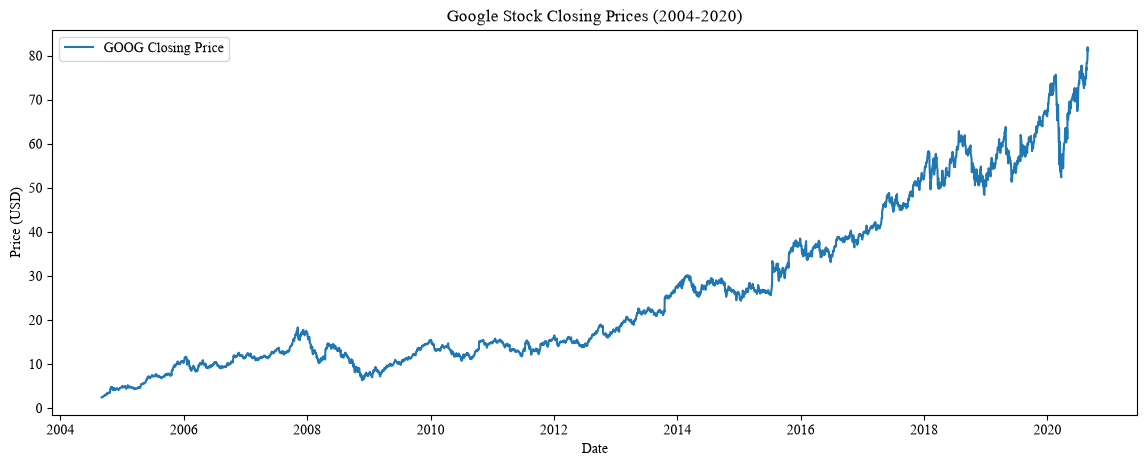

In [ ]:
# Get data on the ticker
tickerData = yf.Ticker('GOOG')

# Get the historical prices for this ticker
Gdata = tickerData.history(start='2004-09-01', end='2020-08-31')

plt.figure(figsize=(14, 5))
plt.plot(Gdata['Close'], label='GOOG Closing Price')
plt.title('Google Stock Closing Prices (2004-2020)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()

In [ ]:
test.adf_results(Gdata['Close'],regression_type='ct')

Test Statistic               -0.777297
p-value                       0.967543
Number of lags                      26
Decision                Non-Stationary
Critical Value (1%)          -3.961035
Critical Value (5%)          -3.411588
Critical Value (10%)         -3.127697
Name: ADF, dtype: object

It seems we cannot reject $H_0$. It does not look like a **mean reverting** time series.

## **Mean reversion VS stationarity**
<hr style="margin-top: -20px;">

Testing for mean reversion and testing for stationarity are related but distinct concepts in time series analysis.

<div align="center">

|Mean Reversion Testing| Stationarity Testing|
|:---------------------|:--------------------|
|Mean reversion testing is focused on whether a time series<br> will return to a specific level (the mean).|Stationarity testing checks if the overall statistical properties<br> of the series remain consistent over time.|
|A mean-reverting series must have some stationarity, particularly in its mean,<br> but or other properties (e.g., variance) might change over time.| A stationary time series may or may not be mean reverting. <br>&bull; A stationary series with a constant mean and variance over time <br>might still not revert to its mean after a shock.|

</div>

## **Predictability of a Time-Series: The Hurst Component**
<hr style="margin-top: -20px;">

The Hurst exponent ($H$) is a measure used to characterize the long-term memory of time series. It helps to determine the presence of autocorrelation or persistence in the data. The goal of the Hurst exponent is to provide us with a scalar value that will help us to identify whether a series is
- **Random walking** - If a variance of a time series is linear with time, it is considered a random walk since variance increases with time.
- **Trending** - If the variance is increasing exponentially or geometrically or faster than time, it go away from its mean with a trend.
- **mean reverting** - If the variance is decreasing with time, roughly speaking, it reverts to its mean in the future since its variance is smaller in the future.

The key insight is that, if any _autocorrelation exists_, then

$$
Var(X(t+\tau)-X(t)) \propto \tau^{2H}
$$

where $H$ is the Hurst exponent. Hurst exponent always range between 0 and 1 and based on the value of $H$:
- $H < 0.5$ : mean-reversion to the long-term mean (anti-persistent)
- $H = 0.5$ : random walk
- $H > 0.5$ : strong trend and long memory effects (persistent)

In [ ]:
def hurst(ts):

    # Create the range of lag values
    lags = range(2, 100)

    # Calculate the array of the variances of the lagged differences
    tau = [np.var(np.subtract(ts[lag:], ts[:-lag])) for lag in lags]

    # Use a linear fit to estimate the Hurst exponent
    poly = np.polyfit(np.log(lags), np.log(tau), 1)

    # Return the Hurst exponent from the polyfit output
    return poly[0]/2.0

In [ ]:
print(f"GOOG closing price, H: {hurst(Gdata['Close'].values):.2f}")

GOOG closing price, H: 0.41


## **Additional Testing**
<hr style="margin-top: -20px;">

Depending on the model and analysis we are pursuing, we may need to test for additional assumptions against the observed dataset or the model's residuals. For example, testing for **homoskedasticity** and **normality**.
- **Homoskedasticity** means that the variance is stable over time. More specifically, it is the variance of the residuals. When the variance is not constant, changing over time, we call it **heteroskedasticity**.
- Another assumption we will need to test for is **normality**; We may want to check the normality of the residuals as well, which can be part of the model diagnostics stage. Therefore, it is important to be aware of the assumptions made by specific models or techniques so you can determine which test to use and against which dataset.

We will run a simple autoregressive (AR(1)) model to demonstrate how we can use different testing against the residuals of a model.

In [ ]:
from statsmodels.tsa.api import AutoReg

df_model = imputed_ts[imputed_ts['LCLid']==np.random.choice(imputed_ts.LCLid.unique())]
df_model_prep = df_model['energy_consumption']
df_model_prep.index = df_model['timestamp']
model = AutoReg(df_model_prep,lags=1).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:     energy_consumption   No. Observations:                28608
Model:                     AutoReg(1)   Log Likelihood                9248.926
Method:               Conditional MLE   S.D. of innovations              0.175
Date:                Mon, 10 Aug 2026   AIC                         -18491.852
Time:                        19:23:28   BIC                         -18467.068
Sample:                    07-12-2012   HQIC                        -18483.882
                         - 02-27-2014                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.0715      0.001     49.905      0.000       0.069       0.074
energy_consumption.L1     0.6914      0.004    161.776      0.000       0.683       0.700
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1            1.4464           +0.0000j            1.4464            0.0000
-----------------------------------------------------------------------------
"""

**Testing Normality**

The statsmodels library and the SciPy library have overlapping implementations. For example, the `Kolmogorov-Smirnov` test is implemented as `ktest` in SciPy and `ktest_normal` in statsmodels. In SciPy, the `D'Agostino-Pearson` test is implemented as `normaltest` and the `Shapiro-Wilk` test as `shapiro`.

The normality diagnostic is a statistical test based on a null hypothesis that we need to determine whether we can accept or reject. Conveniently, the following tests that
we will implement have the same null hypothesis.
_<p align="center">The null hypothesis states that the data is normally distributed;</p>_
Therefore, we would reject the null hypothesis if the p-value is less than 0.05, making the time series not normally distributed.  

In [ ]:
def is_normal(test, p_level=0.05):
    stat, pval = test
    return 'Normal' if pval > 0.05 else 'Not Normal'

In [ ]:
from scipy.stats import shapiro, kstest, normaltest
from statsmodels.stats.diagnostic import kstest_normal

raw_resid = model.resid
std_resid = raw_resid / np.sqrt(model.sigma2)

print(is_normal(shapiro(std_resid)))
print(is_normal(normaltest(std_resid)))
print(is_normal(kstest_normal(std_resid)))
print(is_normal(kstest(std_resid,cdf='norm')))

Not Normal
Not Normal
Not Normal
Not Normal


The output indicates the residuals are not normally distributed. This fact, residuals not being normally distributed, is not enough to determine the model's validity or potential improvements. But taken into context with the other tests, it should help us determine how good our model is.

**Testing  homoskedactisity**

We will perform a **homoskedasticity test** on the model's residuals. As stated earlier regarding statistical tests, it is vital to understand the hypothesis behind these
tests. _The null hypothesis states that the data is homoskedastic_ for the two tests. For example, we would reject the null hypothesis if the p-value is less than 0.05,
making the time series **heteroskedastic**. Let's create a small function, calling it `het_test(model, test)`, that takes in a model and the test function and returns either Heteroskedastic or Homoskedastic based on the p-value to determine whether the null hypothesis is accepted or rejected.

In [ ]:
from statsmodels.stats.api import (het_breuschpagan,
                                   het_white)
from statsmodels.tools.tools import add_constant

def het_test(model, test: function=het_breuschpagan, p_level=0.05):
    """
    Determines if residuals exhibit heteroskedasticity based on test statistics.

    Parameters:
        model: Fitted model object containing residuals and fitted values
        test: Statistical test function (default: het_breuschpagan)
        p_level: Significance level (default: 0.05)

    Returns:
        str: 'Homoskedastic' if p-value > p_level, 'Heteroskedastic' otherwise
    """
    lm, lm_pvalue, fvalue, f_pvalue = test(
        std_resid,
        add_constant(model.fittedvalues)
    ) # pyright: ignore[reportCallIssue]

    return "Heteroskedastic" if f_pvalue < p_level else "Homoskedastic"

In [ ]:
print("Breusch-Pagan Test:", het_test(model, test=het_breuschpagan))
print("White Test:", het_test(model, test=het_white)) # pyright: ignore[reportCallIssue]

Breusch-Pagan Test: Heteroskedastic
White Test: Heteroskedastic


The AutoReg model comes with two useful methods: `diagnostic_summary()` and `plot_diagnostics()`.

In [ ]:
print(model.diagnostic_summary())

             Test of Normality              
Jarque-Bera    P-value   Skewness   Kurtosis
--------------------------------------------
 157993.209      0.000      1.932     13.845


    Test of Conditional Homoskedasticity   
       Lag    ARCH-LM    P-value         DF
-------------------------------------------
         1    918.549      0.000          1
         2   1310.143      0.000          2
         3   1329.722      0.000          3
         4   1332.284      0.000          4
         5   1335.792      0.000          5
         6   1335.768      0.000          6
         7   1335.715      0.000          7
         8   1336.076      0.000          8
         9   1336.478      0.000          9
        10   1346.454      0.000         10
-------------------------------------------


<Figure size 1500x800 with 0 Axes>

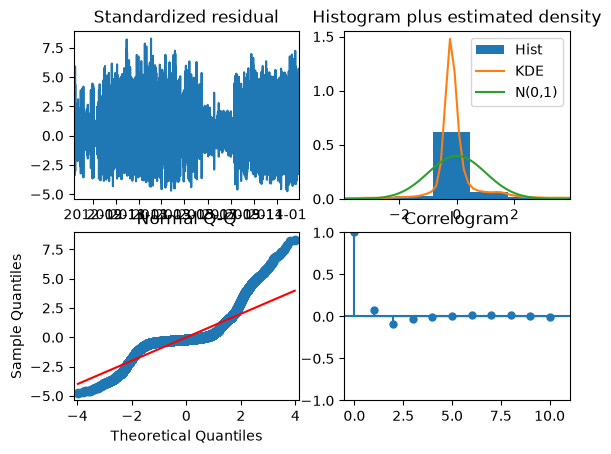

In [ ]:
plt.style.use('default')
plt.figure(figsize=(15,8))

model.plot_diagnostics();

**Testing for Autocorrelation**

Autocorrelation is like statistical correlation which measures the strength of a linear relationship between two variables, except that we measure the linear relationship between time series values separated by a lag. In other words, we are comparing a variable with its lagged version of itself. We will perform a `Ljung-Box test` to check for autocorrelations up to a specified lag and whether they are significantly far off from 0.
_<p align='center'>The null hypothesis for the Ljung-Box test states that the previous lags are not correlated with the current period. </p>_

In other words, we are testing for the absence of autocorrelation. When running the test using `acorr_ljungbox` from statsmodels, we need to provide a **lag** value. The test will run for all lags up to the specified lag (maximum lag).

In [ ]:
df_model_prep

timestamp
2012-07-12 00:00:00+00:00    0.104
2012-07-12 00:30:00+00:00    0.098
2012-07-12 01:00:00+00:00    0.103
2012-07-12 01:30:00+00:00    0.097
2012-07-12 02:00:00+00:00    0.105
                             ...  
2014-02-27 21:30:00+00:00    0.240
2014-02-27 22:00:00+00:00    0.235
2014-02-27 22:30:00+00:00    0.194
2014-02-27 23:00:00+00:00    0.899
2014-02-27 23:30:00+00:00    1.166
Name: energy_consumption, Length: 28608, dtype: float64

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_test = acorr_ljungbox(df_model_prep,
                            lags=12,
                            return_df=True)
ljung_test['eval'] = ljung_test['lb_pvalue'] < 0.05
print(ljung_test)

         lb_stat  lb_pvalue  eval
1   13662.260638        0.0  True
2   18771.664108        0.0  True
3   21074.746101        0.0  True
4   22267.491129        0.0  True
5   22953.688494        0.0  True
6   23387.818503        0.0  True
7   23647.596861        0.0  True
8   23786.216840        0.0  True
9   23838.415095        0.0  True
10  23848.197204        0.0  True
11  23848.236177        0.0  True
12  23852.240295        0.0  True


In [ ]:
# evalauate model using standardized residuals
ljung_test_resid = acorr_ljungbox(
            std_resid,
            return_df=True,
            lags=12)

ljung_test_resid['eval'] = ljung_test_resid['lb_pvalue'] < 0.05
print(ljung_test_resid)

       lb_stat     lb_pvalue  eval
1   151.266996  9.162883e-35  True
2   403.899979  1.968946e-88  True
3   424.516147  1.082422e-91  True
4   424.739764  1.253329e-90  True
5   425.429094  9.780578e-90  True
6   434.079718  1.308693e-90  True
7   439.949549  6.389495e-91  True
8   446.008734  2.648977e-91  True
9   446.529114  1.583036e-90  True
10  447.470511  7.236667e-90  True
11  448.345487  3.240014e-89  True
12  451.708781  4.095664e-89  True


**Granger Causality Testing**

The Granger causality test is a statistical hypothesis test for determining whether one time series is a factor and offer useful information in forecasting another time series. While it is fairly easy to measure correlations between series - when one goes up the other goes up, and vice versa - it's another thing to observe changes in one series correlated to changes in another after a consistent amount of time.

This may indicate the presence of `causality`, that changes in the first series influenced the behavior of the second. However, it may also be that both series are affected by some third factor, just at different rates. Still, it can be useful if changes in one series can predict upcoming changes in another, whether there is causality or not. In this case we say that one series "Granger-causes" another.

In the case of two series, $y$ and $x$, the null hypothesis is that lagged values of $x$ do not explain variations in $y$. In other words, it assumes that $x_t$ doesn’t Granger-cause $y_t$.

The stattools `grangercausalitytests` function offers four tests for granger non-causality of 2 timeseries.

Let's use the Google Stock Price **open** and **close** datasets.

<Axes: xlabel='Date'>

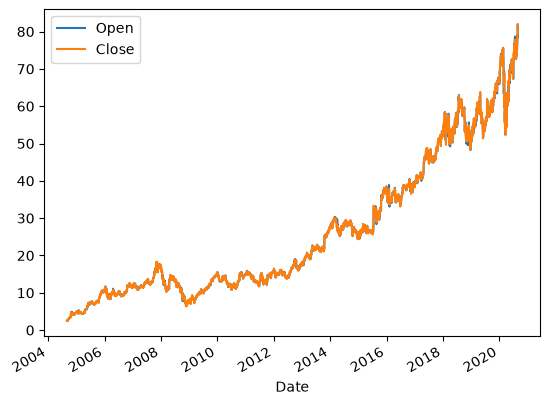

In [ ]:
Gdata_red = Gdata[['Open','Close']]
Gdata_oc = Gdata_red.resample('D').mean().dropna()
Gdata_oc.plot()

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

# Add a semicolon at the end to avoid duplicate output
grangercausalitytests(Gdata_oc[['Open','Close']],maxlag=3);


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=5164.7082, p=0.0000  , df_denom=4023, df_num=1
ssr based chi2 test:   chi2=5168.5596, p=0.0000  , df=1
likelihood ratio test: chi2=3324.8263, p=0.0000  , df=1
parameter F test:         F=5164.7082, p=0.0000  , df_denom=4023, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2569.7069, p=0.0000  , df_denom=4020, df_num=2
ssr based chi2 test:   chi2=5145.8061, p=0.0000  , df=2
likelihood ratio test: chi2=3314.5886, p=0.0000  , df=2
parameter F test:         F=2569.7069, p=0.0000  , df_denom=4020, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1723.2494, p=0.0000  , df_denom=4017, df_num=3
ssr based chi2 test:   chi2=5178.7568, p=0.0000  , df=3
likelihood ratio test: chi2=3328.7601, p=0.0000  , df=3
parameter F test:         F=1723.2494, p=0.0000  , df_denom=4017, df_num=3


In [ ]:
# Get data on the ticker
tickerData = yf.Ticker('AAPL')

# Get the historical prices for this ticker
Adata = tickerData.history(start='2004-09-01', end='2020-08-31')

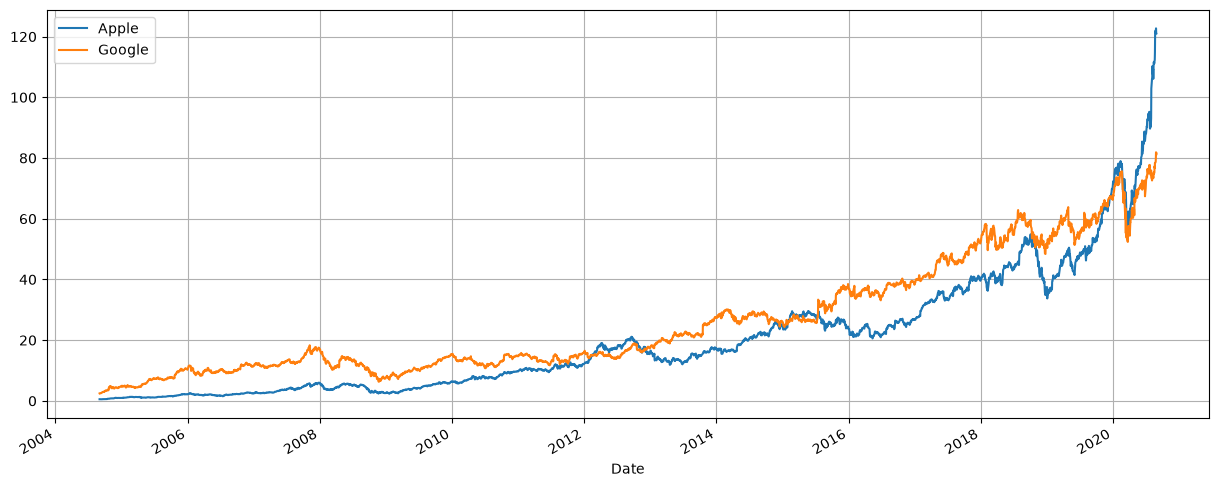

In [ ]:
fig,ax = plt.subplots(figsize=(15,6))
Adata['Close'].plot(ax=ax,label='Apple')
Gdata['Close'].plot(ax=ax,label='Google')
plt.legend()
plt.grid(True)

In [ ]:
merged_df = pd.concat([Gdata['Close'].rename('GClose'),Adata['Close'].rename('AClose')],axis=1)
grangercausalitytests(merged_df[['GClose','AClose']],maxlag=3);


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=7.1198  , p=0.0077  , df_denom=4023, df_num=1
ssr based chi2 test:   chi2=7.1251  , p=0.0076  , df=1
likelihood ratio test: chi2=7.1188  , p=0.0076  , df=1
parameter F test:         F=7.1198  , p=0.0077  , df_denom=4023, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=53.1476 , p=0.0000  , df_denom=4020, df_num=2
ssr based chi2 test:   chi2=106.4274, p=0.0000  , df=2
likelihood ratio test: chi2=105.0446, p=0.0000  , df=2
parameter F test:         F=53.1476 , p=0.0000  , df_denom=4020, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=39.3008 , p=0.0000  , df_denom=4017, df_num=3
ssr based chi2 test:   chi2=118.1077, p=0.0000  , df=3
likelihood ratio test: chi2=116.4076, p=0.0000  , df=3
parameter F test:         F=39.3008 , p=0.0000  , df_denom=4017, df_num=3


In order to draw an inference from the test, we can create a causation matrix and interpret the results.

In [ ]:
def grangers_causation_matrix(data, variables, test='ssr_chi2test',maxlag=15, verbose=False):

    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(maxlag)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df

In [ ]:
grangers_causation_matrix(merged_df,variables=merged_df.columns)

,GClose_x,AClose_x
GClose_y,1.0,0.0
AClose_y,0.0,1.0


The row are the response (y) and the columns are the predictors (x). If a given p-value is < significance level (0.05), for example, take the value 0.0 in (row 1, column 2), we can reject the null hypothesis and conclude that `AClose_x` Granger causes `GClose_y`. Likewise, the 0.0 in (row 2, column 1) refers to `AClose_y` Granger causes `GClose_x`. In simple terms, **Google closing stock prices** seems to granger cause **Apple closing stock prices** and vice versa.